In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np 
from scipy.optimize import curve_fit
import os

In [2]:
rc = lambda r,c:pl.Config(set_tbl_rows=r,set_tbl_cols=c)

In [3]:
jan_2026_data_205nm = pl.read_csv('Processed data/260105 seeded/UV values.csv',
                           new_columns=['temp','sup conc. (205nm)','Incubation time (days)']).with_columns(
    pl.col('Incubation time (days)').cast(pl.Float64),
    pl.col('sup conc. (205nm)')/1000 #to get µM
).sort(by='sup conc. (205nm)')
jan_2026_data_205nm

temp,sup conc. (205nm),Incubation time (days)
i64,f64,f64
21,0.015746,2.0
37,0.01682,7.0
37,0.017309,7.0
37,0.01953,2.0
21,0.020807,7.0
…,…,…
80,0.761885,7.0
80,0.808929,2.0
80,0.821352,2.0


In [4]:
jan_2026_data_MS = pl.read_csv('Processed data/260105 seeded/MS values.csv',
                           new_columns=['temp','sup conc. (MS)','Incubation time (days)']).with_columns(
    pl.col('Incubation time (days)').cast(pl.Float64),
    pl.col('sup conc. (MS)')/1000 #to get µM
).filter(pl.col('temp')<60 # the dried out sample at higher temps had the highest conc.
         #so peptide most likely got too modified to be recognized by the MS and thus can't be trusted
         #might be a problem for some of the 37 °C samples as well
        ).sort(by='sup conc. (MS)')
jan_2026_data_MS

temp,sup conc. (MS),Incubation time (days)
i64,f64,f64
37,0.000897,7.0
37,0.00125,2.0
37,0.001517,7.0
37,0.001603,2.0
37,0.001886,2.0
…,…,…
10,0.079166,2.0
10,0.089385,2.0
10,0.099599,2.0


In [5]:
data_250328_205nm = pl.read_csv('Processed data/250328 5deg/UV values 260122.csv',
                           new_columns=['temp','sup conc. (205nm)','Incubation time (days)']).with_columns(
    pl.col('Incubation time (days)').cast(pl.Float64),
    pl.col('sup conc. (205nm)')/1000 #to get µM
).sort(by='sup conc. (205nm)')
data_250328_205nm

temp,sup conc. (205nm),Incubation time (days)
i64,f64,f64
5,0.028617,4.0
5,0.045467,4.0
5,0.046565,4.0
5,0.062535,4.0
5,0.177083,4.0
5,0.180557,4.0
5,0.182327,4.0
5,0.206775,4.0
5,0.208019,4.0


In [6]:
data_250328_MS = pl.read_csv('Processed data/250328 5deg/MS values 260122.csv',
                           new_columns=['temp','sup conc. (MS)','Incubation time (days)']).with_columns(
    pl.col('Incubation time (days)').cast(pl.Float64),
    pl.col('sup conc. (MS)')/1000 #to get µM
).sort(by='sup conc. (MS)')
data_250328_MS

temp,sup conc. (MS),Incubation time (days)
i64,f64,f64
5,0.024065,4.0
5,0.038286,4.0
5,0.038866,4.0
5,0.051405,4.0
5,0.146069,4.0
5,0.157967,4.0
5,0.169375,4.0
5,0.182702,4.0
5,0.185115,4.0


In [7]:
data_240510_205nm = pl.read_csv('Processed data/240510 wide temp/buffer-corrected values 260115.csv',
                           new_columns=['temp','sup conc. (205nm)','Incubation time (days)']).with_columns(
    pl.col('Incubation time (days)').cast(pl.Float64),
    pl.col('sup conc. (205nm)')/1000 #to get µM
).sort(by='sup conc. (205nm)')
data_240510_205nm

temp,sup conc. (205nm),Incubation time (days)
i64,f64,f64
40,0.031108,5.0
40,0.043656,5.0
30,0.046954,5.0
40,0.051038,5.0
40,0.061519,2.7
…,…,…
70,0.318093,5.0
70,0.429223,5.0
70,0.491739,2.7


In [8]:
data_240510_MS = pl.read_csv('Processed data/240510 wide temp/MS values 260122.csv',
                           new_columns=['temp','sup conc. (MS)','Incubation time (days)']).with_columns(
    pl.col('Incubation time (days)').cast(pl.Float64),
    pl.col('sup conc. (MS)')/1000 #to get µM
).sort(by='sup conc. (MS)')
data_240510_MS

temp,sup conc. (MS),Incubation time (days)
i64,f64,f64
40,0.010816,5.0
40,0.015926,5.0
30,0.016159,5.0
40,0.016794,5.0
23,0.020238,5.0
…,…,…
70,0.135411,5.0
70,0.161421,2.7
70,0.223267,2.7


In [9]:
data_250323_205nm = pl.read_csv('Processed data/250323 70deg/UV values 260127.csv',
                           new_columns=['temp','sup conc. (205nm)','Incubation time (days)']).with_columns(
    pl.col('Incubation time (days)').cast(pl.Float64),
    pl.col('sup conc. (205nm)')/1000 #to get µM
).sort(by='sup conc. (205nm)')
data_250323_205nm

temp,sup conc. (205nm),Incubation time (days)
i64,f64,f64
70,0.731855,2.0
70,1.512442,2.0


In [10]:
data_250323_MS = pl.read_csv('Processed data/250323 70deg/MS values 260127.csv',
                           new_columns=['temp','sup conc. (MS)','Incubation time (days)']).with_columns(
    pl.col('Incubation time (days)').cast(pl.Float64),
    pl.col('sup conc. (MS)')/1000 #to get µM
).sort(by='sup conc. (MS)')
data_250323_MS

temp,sup conc. (MS),Incubation time (days)
i64,f64,f64
70,0.487738,2.0
70,0.778876,2.0


In [11]:
data_240430_205nm = pl.read_csv('Processed data/240430 45 50 55c/UV values.csv',
                           new_columns=['temp','sup conc. (205nm)','Incubation time (days)']).with_columns(
    pl.col('Incubation time (days)').cast(pl.Float64),
    pl.col('sup conc. (205nm)')/1000 #to get µM
).sort(by='sup conc. (205nm)')
data_240430_205nm

temp,sup conc. (205nm),Incubation time (days)
i64,f64,f64
45,0.054366,2.0
45,0.069094,2.0
50,0.075468,2.0
50,0.079646,2.0
50,0.096874,2.0
…,…,…
55,0.106367,2.0
55,0.111686,2.0
55,0.14011,4.0


In [12]:
data_240430_MS = pl.read_csv('Processed data/240430 45 50 55c/MS values.csv',
                           new_columns=['temp','sup conc. (MS)','Incubation time (days)']).with_columns(
    pl.col('Incubation time (days)').cast(pl.Float64),
    pl.col('sup conc. (MS)')/1000 #to get µM
).sort(by='sup conc. (MS)')
data_240430_MS

temp,sup conc. (MS),Incubation time (days)
i64,f64,f64
45,0.036495,2.0
45,0.044081,2.0
50,0.050679,2.0
50,0.055733,2.0
50,0.068876,2.0
…,…,…
55,0.084866,2.0
55,0.086269,2.0
55,0.114778,4.0


In [13]:
rc(20,20)

In [14]:
# df = pl.concat([old_data.select(['temp','sup conc. (205nm)','sup conc. (MS)','Incubation time (days)'])
#                 ,jan_2026_data_205nm,jan_2026_data_MS,
#                data_250328_205nm,data_250328_MS],how='diagonal')
# df.sort(by='temp')

In [15]:
df_unseeded = pl.concat([
    data_240430_205nm,data_240430_MS,
    data_240510_205nm,data_240510_MS,
    data_250323_205nm,data_250323_MS,
    data_250328_205nm,data_250328_MS],
                        how='diagonal')
df_unseeded.sort(by='temp')

temp,sup conc. (205nm),Incubation time (days),sup conc. (MS)
i64,f64,f64,f64
5,0.028617,4.0,null
5,0.045467,4.0,null
5,0.046565,4.0,null
5,0.062535,4.0,null
5,0.177083,4.0,null
5,0.180557,4.0,null
5,0.182327,4.0,null
5,0.206775,4.0,null
5,0.208019,4.0,null


In [16]:
df_unseeded.describe()

statistic,temp,sup conc. (205nm),Incubation time (days),sup conc. (MS)
str,f64,f64,f64,f64
"""count""",96.0,48.0,96.0,48.0
"""null_count""",0.0,48.0,0.0,48.0
"""mean""",36.833333,0.192372,3.610417,0.109734
"""std""",22.295936,0.25774,1.186989,0.133629
"""min""",5.0,0.028617,2.0,0.010816
"""25%""",18.0,0.069094,2.7,0.038286
"""50%""",40.0,0.104317,4.0,0.055733
"""75%""",55.0,0.182327,5.0,0.135411
"""max""",70.0,1.512442,5.0,0.778876


# Plotting

## plotting parameters

In [17]:
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["font.family"] = 'serif'
plt.rcParams["font.serif"] = ["cmr10"]
plt.rcParams["mathtext.fontset"]='cm'
plt.rcParams["font.size"] = 10
cm_to_inch=1/2.54
fig_size = (8.7*cm_to_inch,6*cm_to_inch)

In [18]:
# #plt.figure(figsize=fig_size)
# plt.scatter(df['temp'],df['sup conc. (MS)'],c=df['Incubation time (days)']
#              ,cmap='winter_r',label='By MS',marker='o')
# # plt.errorbar(df['temp'],df['sup conc. (MS)'],df['MS std'],alpha=0.5,
# #              marker=' ',linestyle=' ',capsize=2,color='black')
# plt.scatter(df['temp'],df['sup conc. (205nm)'],c=df['Incubation time (days)']
#              ,cmap='winter_r',
#              label='By UV (205nm)',marker='x')
# # plt.errorbar(df['temp'],df['sup conc. (205nm)'],df['205 std'],
# #              marker=' ',linestyle=' ',alpha=0.5,
# #              capsize=2,color='black')

# plt.semilogy()
# plt.grid(which='both')
# plt.legend(fontsize=8,scatterpoints=4)
# plt.colorbar(label='Incubation time (days)')
# plt.xlabel(r'Temperature / $^\circ$C')
# plt.ylabel(r'Solubility / $\mu M$')
# plt.tight_layout()
# #plt.savefig('plots/ABm1-42-temp-dep-sol-log-UV-and-MS.pdf')

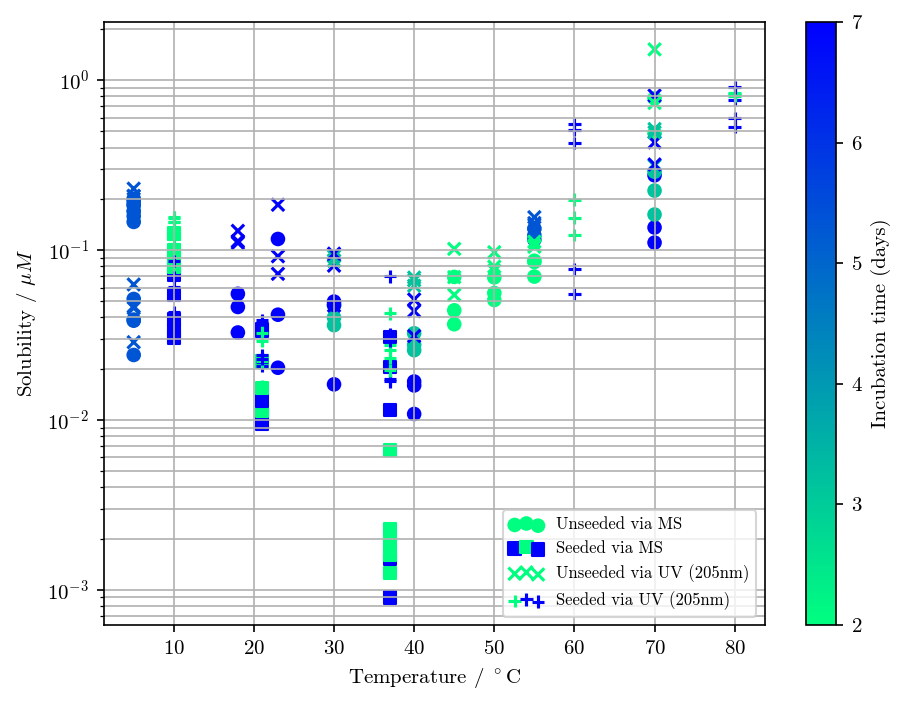

In [19]:
#plt.figure(figsize=fig_size)
#Unseeded:
plt.scatter(df_unseeded.drop_nulls('sup conc. (MS)')['temp'],df_unseeded.drop_nulls('sup conc. (MS)')['sup conc. (MS)'],
            c=df_unseeded.drop_nulls('sup conc. (MS)')['Incubation time (days)']
             ,cmap='winter_r',label='Unseeded via MS',marker='o')

#Seeded:
plt.scatter(jan_2026_data_MS['temp'],jan_2026_data_MS['sup conc. (MS)'],c=jan_2026_data_MS['Incubation time (days)']
             ,cmap='winter_r',label='Seeded via MS',marker='s')

#Unseeded:
plt.scatter(df_unseeded['temp'],df_unseeded['sup conc. (205nm)'],c=df_unseeded['Incubation time (days)']
             ,cmap='winter_r',
             label='Unseeded via UV (205nm)',marker='x')

#Seeded:
plt.scatter(jan_2026_data_205nm['temp'],jan_2026_data_205nm['sup conc. (205nm)'],c=jan_2026_data_205nm['Incubation time (days)']
             ,cmap='winter_r',
             label='Seeded via UV (205nm)',marker='+')
# plt.errorbar(df['temp'],df['sup conc. (205nm)'],df['205 std'],
#              marker=' ',linestyle=' ',alpha=0.5,
#              capsize=2,color='black')


plt.grid(which='both')
plt.legend(fontsize=8,scatterpoints=3,loc='lower right')
plt.semilogy()
plt.colorbar(label='Incubation time (days)')
plt.xlabel(r'Temperature / $^\circ$C')
plt.ylabel(r'Solubility / $\mu M$')
plt.tight_layout()
plt.savefig('plots/ABm1-42-temp-dep-sol-log-UV-and-MS-time-resolved-seeded-vs-unseeded.pdf')

# Fitting

$s = \exp\left(\frac{\mu_f^\circ-\mu_m^\circ}{RT}\right) = \exp\left(\frac{\Delta \mu^\circ}{RT}\right)$

$    \Delta \mu^\circ(T) = \Delta C_p[(T-T_h) - T\ln(T/T_s)] $

In [20]:
def dm(T,dCp,Th,Ts):
    return dCp*((T-Th)-T*np.log(T/Ts))

In [21]:
def c_at_eq(T,dCp,Th,Ts):
    R= 8.31446261815324 # J⋅K^−1⋅mol^−1
    c=np.exp(dm(T,dCp,Th,Ts)/(R*T))
    return c

In [22]:
T=np.linspace(274,373,100)


In [23]:
df=pl.concat([df_unseeded,jan_2026_data_205nm,jan_2026_data_MS],how='diagonal')

In [24]:
df

temp,sup conc. (205nm),Incubation time (days),sup conc. (MS)
i64,f64,f64,f64
45,0.054366,2.0,null
45,0.069094,2.0,null
50,0.075468,2.0,null
50,0.079646,2.0,null
50,0.096874,2.0,null
45,0.101338,2.0,null
55,0.104317,2.0,null
55,0.106367,2.0,null
55,0.111686,2.0,null


In [43]:
df.group_by('temp').mean().sort(by='temp')

temp,sup conc. (205nm),Incubation time (days),sup conc. (MS)
i64,f64,f64,f64
5,0.136715,4.0,0.1194
10,0.102335,4.5,0.074574
18,0.117239,5.0,0.044622
21,0.02494,4.5,0.018374
23,0.116043,5.0,0.05922
30,0.081167,3.85,0.039385
37,0.030303,4.5,0.00785
40,0.053711,3.85,0.02152
45,0.074933,2.0,0.049959


In [26]:
UV_mean=df.group_by('temp').mean().select(['temp','sup conc. (205nm)'])
UV_std=df.group_by('temp').agg([pl.std("sup conc. (205nm)").alias("205 std_dev")])
MS_mean=df.group_by('temp').mean().select(['temp','sup conc. (MS)'])
MS_std=df.group_by('temp').agg([pl.std("sup conc. (MS)").alias("MS std_dev")])

In [27]:
df2=pl.concat([UV_mean,UV_std,MS_mean,MS_std],how='align')
df2

temp,sup conc. (205nm),205 std_dev,sup conc. (MS),MS std_dev
i64,f64,f64,f64,f64
5,0.136715,0.080153,0.1194,0.07174
10,0.102335,0.045177,0.074574,0.03514
18,0.117239,0.01056,0.044622,0.011313
21,0.02494,0.006609,0.018374,0.009317
23,0.116043,0.05986,0.05922,0.050222
30,0.081167,0.017464,0.039385,0.012487
37,0.030303,0.015855,0.00785,0.010157
40,0.053711,0.014573,0.02152,0.008229
45,0.074933,0.024024,0.049959,0.017174


In [28]:
popt, pcov = curve_fit( c_at_eq,
                       pl.concat([df2.drop_nulls('MS std_dev')['temp']+273,df2.drop_nulls('205 std_dev')['temp']+273]),
                       pl.concat([df2.drop_nulls('MS std_dev')['sup conc. (MS)'],df2.drop_nulls('205 std_dev')['sup conc. (205nm)']]),
                    p0=[-6e2, 313,313],
                  sigma=pl.concat([df2.drop_nulls('MS std_dev')['MS std_dev'],df2.drop_nulls('205 std_dev')['205 std_dev']])
                      )
perr = np.sqrt(np.diag(pcov))

popt

array([-2527.09850444,   304.4048354 ,   307.74660082])

In [29]:
np.linalg.cond(pcov) # this should be low, otherwise a sign of overparametrization.

np.float64(26991300.891821887)

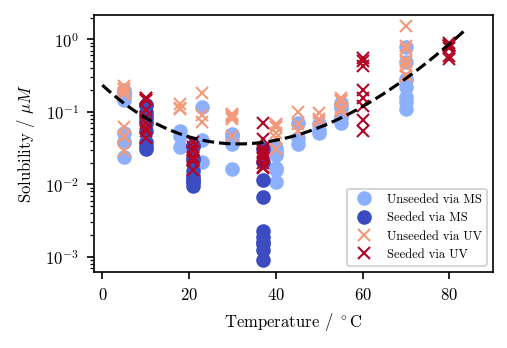

In [30]:
plt.rcParams["font.size"] = 8

T=np.linspace(273,357,100)
cmp = plt.get_cmap('coolwarm',5)

plt.figure(figsize=fig_size)
plt.plot(df_unseeded['temp'],df_unseeded['sup conc. (MS)'],
             marker='o',linestyle=' ',color=cmp(1),label='Unseeded via MS')
plt.plot(jan_2026_data_MS['temp'],jan_2026_data_MS['sup conc. (MS)'],
             marker='o',linestyle=' ',color=cmp(0),label='Seeded via MS')

plt.plot(df_unseeded['temp'],df_unseeded['sup conc. (205nm)'],
             marker='x',linestyle=' ',color=cmp(3),label='Unseeded via UV')
plt.plot(jan_2026_data_205nm['temp'],jan_2026_data_205nm['sup conc. (205nm)'],
             marker='x',linestyle=' ',color=cmp(4),label='Seeded via UV')
plt.semilogy(T-273,c_at_eq(T,popt[0],popt[1],popt[2]),color='black',linestyle='--')

plt.xlim(-2,90)
#plt.ylim(0.005,10)
#plt.title(r'Fitted as Phase transition')
plt.xlabel(r'Temperature / $^\circ$C')
plt.ylabel(r'Solubility / $\mu M$')
plt.legend(fontsize=6)
plt.tight_layout()
plt.savefig('plots/weighted-fit-log-legend.pdf')

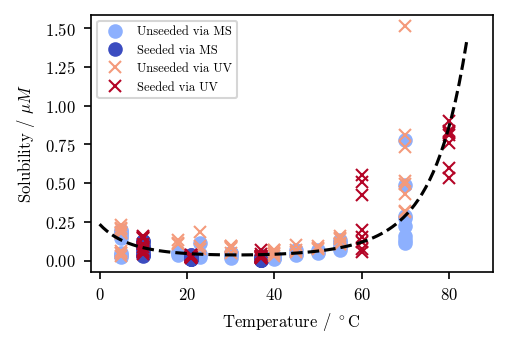

In [31]:
T=np.linspace(273,357,100)
cmp = plt.get_cmap('coolwarm',5)

plt.figure(figsize=fig_size)
plt.plot(df_unseeded['temp'],df_unseeded['sup conc. (MS)'],
             marker='o',linestyle=' ',color=cmp(1),label='Unseeded via MS')
plt.plot(jan_2026_data_MS['temp'],jan_2026_data_MS['sup conc. (MS)'],
             marker='o',linestyle=' ',color=cmp(0),label='Seeded via MS')
plt.plot(df_unseeded['temp'],df_unseeded['sup conc. (205nm)'],
             marker='x',linestyle=' ',color=cmp(3),label='Unseeded via UV')
plt.plot(jan_2026_data_205nm['temp'],jan_2026_data_205nm['sup conc. (205nm)'],
             marker='x',linestyle=' ',color=cmp(4),label='Seeded via UV')
plt.plot(T-273,c_at_eq(T,popt[0],popt[1],popt[2]),color='black',linestyle='--')

plt.xlim(-2,90)
#plt.ylim(0.005,10)
#plt.title(r'Fitted as Phase transition')
plt.xlabel(r'Temperature / $^\circ$C')
plt.ylabel(r'Solubility / $\mu M$')
plt.legend(fontsize=6)
plt.tight_layout()
plt.savefig('plots/weighted-fit-legend.pdf')

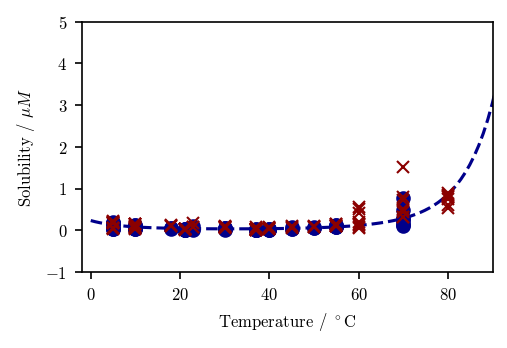

In [32]:
T=np.linspace(273,373,100)

plt.figure(figsize=fig_size)
plt.plot(T-273,c_at_eq(T,popt[0],popt[1],popt[2]),color='darkblue',linestyle='--')
plt.plot(df['temp'],df['sup conc. (MS)'],
             marker='o',linestyle=' ',color='darkblue',label='MS (TIC)')
plt.plot(df['temp'],df['sup conc. (205nm)'],
             marker='x',linestyle=' ',color='darkred',label='UV (205nm)')
plt.xlim(-2,90)
plt.ylim(-1,5)
#plt.title(r'Fitted as Phase transition')
plt.xlabel(r'Temperature / $^\circ$C')
plt.ylabel(r'Solubility / $\mu M$')
plt.tight_layout()
plt.savefig('plots/weighted-fit.pdf')

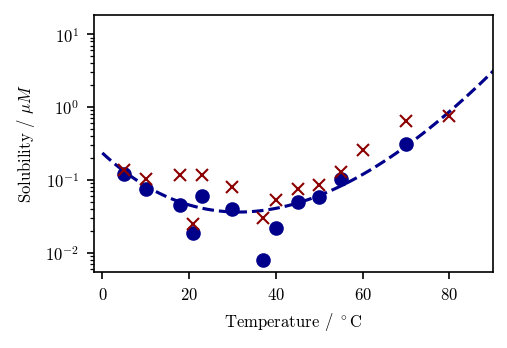

In [33]:
plt.figure(figsize=fig_size)
plt.semilogy(T-273,c_at_eq(T,popt[0],popt[1],popt[2]),color='darkblue',linestyle='--')
plt.plot(df.group_by('temp').mean().sort(by='temp')['temp'],df.group_by('temp').mean().sort(by='temp')['sup conc. (MS)'],
             marker='o',linestyle=' ',color='darkblue',label='MS (TIC)')
plt.plot(df.group_by('temp').mean().sort(by='temp')['temp'],df.group_by('temp').mean().sort(by='temp')['sup conc. (205nm)'],
             marker='x',linestyle=' ',color='darkred',label='UV (205nm)')
plt.xlim(-2,90)
#plt.ylim(0.005,10)
#plt.title(r'Fitted as Phase transition')
plt.xlabel(r'Temperature / $^\circ$C')
plt.ylabel(r'Solubility / $\mu M$')
plt.tight_layout()
plt.savefig('plots/weighted-fit-log-avgs.pdf')

In [34]:
df.select(['temp', 'sup conc. (205nm)', 'sup conc. (MS)']
       ).group_by('temp'
         ).mean(
         ).sort(by='temp'
         ).with_columns(
    ((pl.col('sup conc. (205nm)')+pl.col('sup conc. (MS)'))/2).alias('mean')
)

temp,sup conc. (205nm),sup conc. (MS),mean
i64,f64,f64,f64
5,0.136715,0.1194,0.128058
10,0.102335,0.074574,0.088455
18,0.117239,0.044622,0.08093
21,0.02494,0.018374,0.021657
23,0.116043,0.05922,0.087632
30,0.081167,0.039385,0.060276
37,0.030303,0.00785,0.019076
40,0.053711,0.02152,0.037615
45,0.074933,0.049959,0.062446


In [35]:
popt

array([-2527.09850444,   304.4048354 ,   307.74660082])

In [36]:
print('dC_p =',round(popt[0]/1e3,2),'±',round(perr[0]/1e3,2),' kJ/mol \n',
      'Th =',round(popt[1]),'±',round(perr[1],2),' K (',round(popt[1])-273,' °C) \n',
      'Ts =',round(popt[2]),'±',round(perr[2],2),' K (',round(popt[2])-273,' °C)'
 )

dC_p = -2.53 ± 0.41  kJ/mol 
 Th = 304 ± 2.49  K ( 31  °C) 
 Ts = 308 ± 2.18  K ( 35  °C)


# Decomposition into $\Delta\mu^\circ$, $\Delta h^\circ$ and $\Delta s^\circ$

$\Delta h^\circ(T) = \Delta C_p(T-T_h)$

$\Delta s^\circ(T) = \Delta C_p\ln(T/T_s) $

In [37]:
def dh(T,dCp,Th):
    return dCp*(T-Th)
def ds(T,dCp,Ts):
    return dCp*np.log(T/Ts)

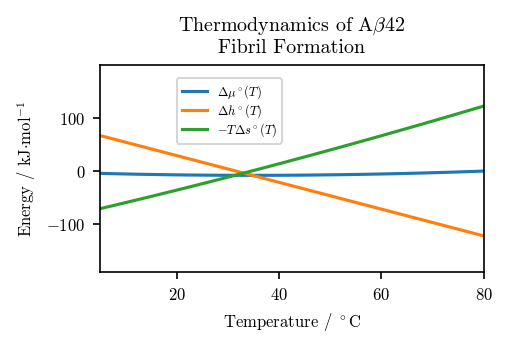

In [38]:
plt.rcParams["font.size"] = 8

plt.figure(figsize=fig_size)

#plt.plot(T-273,dG(T,popt[0],popt[1],popt[2])/1e3,label=r'$\Delta G(T)$')
plt.plot(T-273,dm(T,popt[0],popt[1],popt[2])/1e3,label=r'$\Delta \mu^\circ(T)$')
#plt.plot(T-273,dH(T,popt[0],273.15,popt[2])/1e3,label=r'$\Delta H(T)$')
plt.plot(T-273,dh(T,popt[0],popt[1])/1e3,label=r'$\Delta h^\circ(T)$')
#plt.plot(T-273,-T*dS(T,popt[1],273.15,popt[2])/1e3,label=r'$-T\Delta S(T)$')
plt.plot(T-273,-T*ds(T,popt[0],popt[2])/1e3,label=r'$-T\Delta s^\circ(T)$')

#plt.plot(df['temp'],df['sup conc. (MS)'],marker='o',linestyle=' ')
plt.xlim(5,80)
#plt.ylim(0,10)
plt.title(r'Thermodynamics of A$\beta$42'+'\nFibril Formation')
plt.xlabel(r'Temperature / $^\circ$C')
plt.ylabel(r'Energy / kJ$\cdot$mol$^{-1}$')
plt.legend(fontsize=6,loc=(0.2,0.62),labelspacing=0.1)
plt.tight_layout()
plt.savefig('plots/chemical potential plus components.pdf')

# Th=Ts Misfit

In [39]:
def c_at_eq_one_RefT(T,dCp,Tr):
    R= 8.31446261815324#e-3 # J⋅K^−1⋅mol^−1
    c=np.exp(dm(T,dCp,Tr,Tr)/(R*T))
    return c

In [40]:
popt, pcov = curve_fit( c_at_eq_one_RefT,
                       pl.concat([df2.drop_nulls('MS std_dev')['temp']+273,df2.drop_nulls('205 std_dev')['temp']+273]),
                       pl.concat([df2.drop_nulls('MS std_dev')['sup conc. (MS)'],df2.drop_nulls('205 std_dev')['sup conc. (205nm)']]),
                    p0=[-6e2, 313],
                  sigma=pl.concat([df2.drop_nulls('MS std_dev')['MS std_dev'],df2.drop_nulls('205 std_dev')['205 std_dev']])
                      )
perr = np.sqrt(np.diag(pcov))

popt

array([   8.3776519 , 1779.50659432])

In [41]:
np.linalg.cond(pcov) # this should be low, otherwise a sign of overparametrization.

np.float64(80494614.81716923)

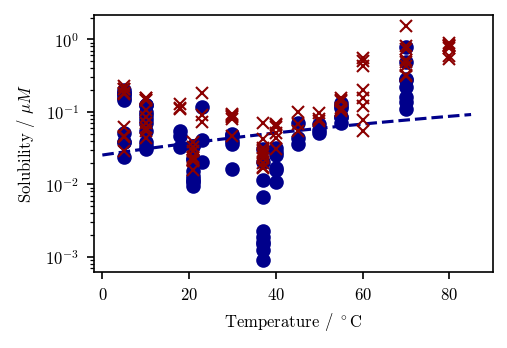

In [42]:
T=np.linspace(273,358,100)

plt.figure(figsize=fig_size)
plt.semilogy(T-273,c_at_eq_one_RefT(T,popt[0],popt[1]),color='darkblue',linestyle='--')
plt.plot(df['temp'],df['sup conc. (MS)'],
             marker='o',linestyle=' ',color='darkblue',label='MS (TIC)')
plt.plot(df['temp'],df['sup conc. (205nm)'],
             marker='x',linestyle=' ',color='darkred',label='UV (205nm)')
plt.xlim(-2,90)
#plt.ylim(0.005,10)
#plt.title(r'Fitted as Phase transition')
plt.xlabel(r'Temperature / $^\circ$C')
plt.ylabel(r'Solubility / $\mu M$')
plt.tight_layout()
plt.savefig('plots/weighted-misfit-log-only-one-ref-T.pdf')